# Customer Churn Prediction-Bank Dataset

## Project Overview

Every customer who churns is revenue the bank will never recover. This project uses machine learning to predict which customers are likely to leave early enough to do something about it. Built on 10,000 real bank customer records, the pipeline covers data cleaning, feature engineering, model training and comparison across three algorithms, and a custom churn risk scoring engine that translates predictions into plain business language. 

## Dataset Fields

| Raw Column Name | Mapped Name | Description |
|---|---|---|
| `age` | **Age** | Customer's age in years |
| `estimated_salary` | **Income** | Estimated annual salary (renamed `income`) |
| `products_number` | **Purchases** | Number of bank products held (renamed `purchases`) |
| `country` + `active_member` | **Membership** | Engineered tier: Premium / Standard / Basic |
| `churn` | **Churn** | Target variable - 1 = churned, 0 = retained |


---
##  Import Libraries

All necessary libraries are imported: core data tools (`pandas`, `numpy`), visualisation (`matplotlib`, `seaborn`), scikit-learn preprocessing/model-selection, imbalanced-learn SMOTE, three classifiers, and evaluation metrics. Global display settings are configured.

In [6]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from imblearn.over_sampling import SMOTE


# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

# Display 
import os
os.makedirs('results', exist_ok=True)
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print('All libraries imported successfully.')

All libraries imported successfully.


---
## Load Dataset

The CSV is loaded, `estimated_salary` to `income` and `products_number` to `purchases` are renamed immediately. `customer_id` is dropped as it has no predictive value.

In [7]:
# Load raw dataset
df = pd.read_csv('Bank_Customer_Churn_Prediction.csv')

# Rename columns 
df.rename(columns={
    'estimated_salary': 'income',
    'products_number': 'purchases'
}, inplace=True)

# Drop non-predictive identifier
if 'customer_id' in df.columns:
    df.drop(columns=['customer_id'], inplace=True)
    print("'customer_id' column dropped.")
else:
    print("'customer_id' not found — skipping.")

# Inspect
print(f"\n{'='*50}")
print(f"Dataset Shape : {df.shape}")
print(f"{'='*50}")
print(f"\nColumn Names  : {df.columns.tolist()}")
print(f"\nFirst 5 Rows:")
display(df.head())

'customer_id' column dropped.

Dataset Shape : (10000, 11)

Column Names  : ['credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'purchases', 'credit_card', 'active_member', 'income', 'churn']

First 5 Rows:


,credit_score,country,gender,age,tenure,balance,purchases,credit_card,active_member,income,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


---
## Initial Data Exploration

Covers shape, dtypes, descriptive statistics, `df.info()`, and churn class distribution with imbalance percentage calculation.

In [8]:
# 1. Shape
print(f"{'='*50}\nDataset Shape: {df.shape}\n{'='*50}\n")

# 2. Data Types
print(f"{'='*50}\nData Types:\n{'='*50}")
print(df.dtypes)
print()

# 3. Statistical Summary
print(f"{'='*50}\nStatistical Summary:\n{'='*50}")
display(df.describe())

# 4. Data Info
print(f"{'='*50}\nData Info:\n{'='*50}")
df.info()
print()

# 5. Churn Distribution & Imbalance
print(f"{'='*50}\nChurn Value Counts:\n{'='*50}")
churn_counts = df['churn'].value_counts()
print(churn_counts)
minority = churn_counts.min(); majority = churn_counts.max(); total = churn_counts.sum()
imb_pct = (minority / total) * 100
print(f"\n  Class Imbalance Note:")
print(f"   Churned (class 1)    : {minority:,} ({imb_pct:.1f}%)")
print(f"   Not Churned (class 0): {majority:,} ({100-imb_pct:.1f}%)")
print(f"   Minority class is only {imb_pct:.1f}% — SMOTE will be applied.")

Dataset Shape: (10000, 11)

Data Types:
credit_score       int64
country           object
gender            object
age                int64
tenure             int64
balance          float64
purchases          int64
credit_card        int64
active_member      int64
income           float64
churn              int64
dtype: object

Statistical Summary:


,credit_score,age,tenure,balance,purchases,credit_card,active_member,income,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   credit_score   10000 non-null  int64  
 1   country        10000 non-null  object 
 2   gender         10000 non-null  object 
 3   age            10000 non-null  int64  
 4   tenure         10000 non-null  int64  
 5   balance        10000 non-null  float64
 6   purchases      10000 non-null  int64  
 7   credit_card    10000 non-null  int64  
 8   active_member  10000 non-null  int64  
 9   income         10000 non-null  float64
 10  churn          10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB

Churn Value Counts:
churn
0    7963
1    2037
Name: count, dtype: int64

  Class Imbalance Note:
   Churned (class 1)    : 2,037 (20.4%)
   Not Churned (class 0): 7,963 (79.6%)
   Minority class is only 20.4% — SMOTE will be applied.


---
##  Null & Duplicate Check

Comprehensive audit: standard nulls, hidden nulls (empty/whitespace strings), placeholder nulls ('unknown','N/A','none'), zero-balance counts, and duplicate rows.

In [9]:
issues_found = False

# 1. Standard Nulls
print(f"{'='*50}\n1. Standard Null Check:\n{'='*50}")
null_counts = df.isnull().sum()
print(null_counts)
if null_counts.sum() > 0:
    issues_found = True
    before = len(df); df.dropna(inplace=True)
    print(f"   Dropped {before - len(df)} rows with nulls.")
else:
    print("   No standard nulls found.")
print()

# 2. Hidden Nulls
print(f"{'='*50}\n2. Hidden Null Check:\n{'='*50}")
obj_cols = df.select_dtypes(include='object').columns
h_nulls = {c: df[c].apply(lambda x: isinstance(x,str) and x.strip()=='').sum() for c in obj_cols}
h_nulls = {c:v for c,v in h_nulls.items() if v>0}
if h_nulls:
    issues_found = True
    print(f"  {h_nulls}")
    before = len(df)
    for c in h_nulls: df = df[~df[c].apply(lambda x: isinstance(x,str) and x.strip()=='')]
    print(f"  Dropped {before-len(df)} rows.")
else:
    print("  No hidden null strings found.")
print()

# 3. Placeholder Nulls
print(f"{'='*50}\n3. Placeholder Null Check:\n{'='*50}")
ph = ['unknown','n/a','none','na','null']
p_nulls = {c: df[c].apply(lambda x: isinstance(x,str) and x.strip().lower() in ph).sum()
           for c in obj_cols if c in df.columns}
p_nulls = {c:v for c,v in p_nulls.items() if v>0}
if p_nulls:
    issues_found = True
    print(f"  {p_nulls}")
else:
    print("   No placeholder null values found.")
print()

# 4. Zero-Balance Check
print(f"{'='*50}\n4. Zero-Balance Check:\n{'='*50}")
if 'balance' in df.columns:
    zb = (df['balance'] == 0).sum()
    print(f"   Customers with zero balance: {zb:,} ({zb/len(df)*100:.1f}%)")
    print("    Retained — zero balance is a valid customer state.")
print()

# 5. Duplicates
print(f"{'='*50}\n5. Duplicate Check:\n{'='*50}")
dup = df.duplicated().sum()
print(f"   Duplicate rows: {dup}")
if dup > 0:
    issues_found = True; before = len(df); df.drop_duplicates(inplace=True)
    print(f"  Dropped {before-len(df)} duplicates.")
else:
    print("  No duplicates found.")

print(f"\n{'='*50}")
if not issues_found:
    print("Data is clean: No nulls or duplicates detected. Pipeline is verified.")
else:
    print(f"  Data cleaning complete. Shape: {df.shape}")
print(f"{'='*50}")

1. Standard Null Check:
credit_score     0
country          0
gender           0
age              0
tenure           0
balance          0
purchases        0
credit_card      0
active_member    0
income           0
churn            0
dtype: int64
   No standard nulls found.

2. Hidden Null Check:
  No hidden null strings found.

3. Placeholder Null Check:
   No placeholder null values found.

4. Zero-Balance Check:
   Customers with zero balance: 3,617 (36.2%)
    Retained — zero balance is a valid customer state.

5. Duplicate Check:
   Duplicate rows: 0
  No duplicates found.

Data is clean: No nulls or duplicates detected. Pipeline is verified.


---
## Churn Distribution Visualization

Bar chart + pie chart side-by-side showing class distribution of the target variable.

 Figure saved to 'results/01_churn_distribution.png'


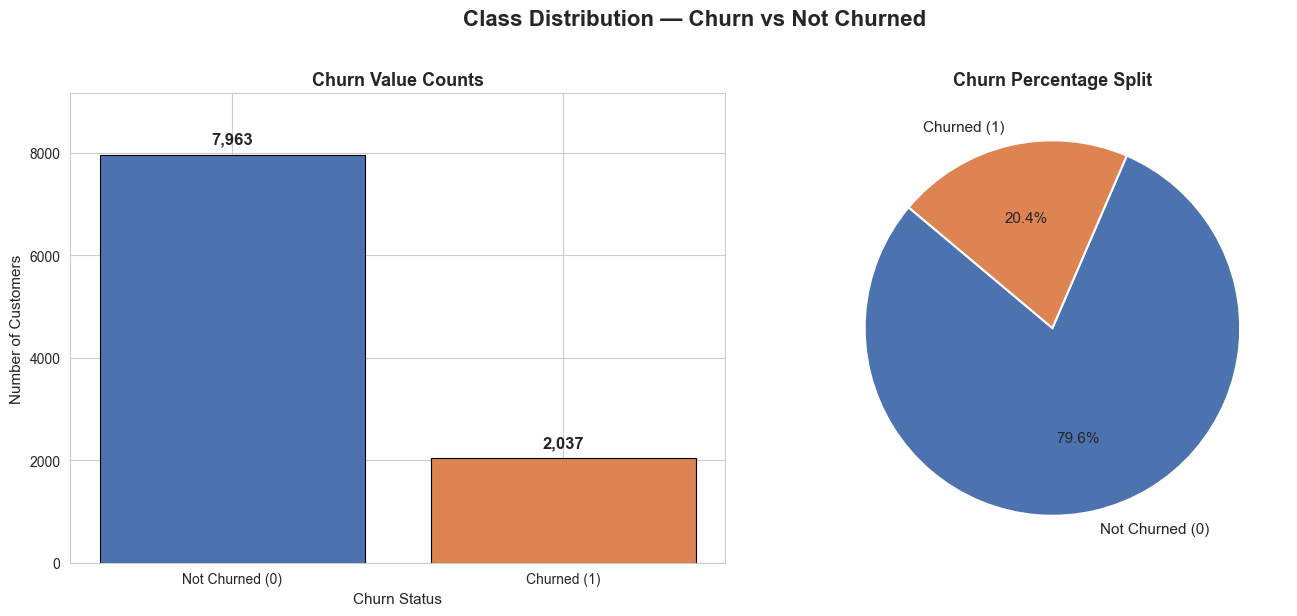

In [11]:
# Prepare
ch = df['churn'].value_counts().sort_index()
labels = ['Not Churned (0)', 'Churned (1)']
colors = ['#4C72B0', '#DD8452']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Class Distribution — Churn vs Not Churned', fontsize=16, fontweight='bold', y=1.02)

# Bar chart
bars = axes[0].bar(labels, ch.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Churn Value Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn Status', fontsize=11)
axes[0].set_ylabel('Number of Customers', fontsize=11)
axes[0].set_ylim(0, ch.max() * 1.15)
for bar in bars:
    h = bar.get_height()
    axes[0].annotate(f'{int(h):,}',
        xy=(bar.get_x()+bar.get_width()/2, h), xytext=(0,8),
        textcoords='offset points', ha='center', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(ch.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=140, wedgeprops={'linewidth':1.5,'edgecolor':'white'},
            textprops={'fontsize':11})
axes[1].set_title('Churn Percentage Split', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('results/01_churn_distribution.png', dpi=150, bbox_inches='tight')
print(" Figure saved to 'results/01_churn_distribution.png'")
plt.show()

---
### Observations-Class Imbalance & Why SMOTE Will Be Applied

The dataset is **imbalanced**: ~80% not churned vs ~20% churned. A naive classifier predicting 'Not Churned' always would achieve ~80% accuracy while being useless. SMOTE synthesizes new minority-class samples by interpolating between existing instances applied **only on the training set** to prevent data leakage.

---
## Data Preprocessing & Cleaning

This section handles outlier removal, skewness correction, zero-balance investigation, feature engineering, encoding, scaling, and class imbalance correction using SMOTE.

---
### Outlier Detection & Removal (IQR Method)

IQR-based outlier removal on `credit_score`, `age`, `balance`, `income`. Rows outside `[Q1 − 1.5×IQR, Q3 + 1.5×IQR]` are dropped to prevent extreme values from distorting model training.

In [12]:
# Outlier Detection & Removal via IQR
outlier_cols = ['credit_score', 'age', 'balance', 'income']

shape_before = df.shape
print(f"{'='*55}")
print(f"Shape BEFORE outlier removal: {shape_before}")
print(f"{'='*55}\n")

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (df[col] < lower) | (df[col] > upper)
    n = mask.sum()
    print(f"  [{col}] Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}")
    print(f"           Bounds: [{lower:.2f}, {upper:.2f}]  →  Outliers: {n}")
    df = df[~mask]
    print()

shape_after = df.shape
print(f"{'='*55}")
print(f"Shape AFTER  outlier removal: {shape_after}")
print(f"Total rows removed          : {shape_before[0] - shape_after[0]}")
print(f"{'='*55}")

Shape BEFORE outlier removal: (10000, 11)

  [credit_score] Q1=584.00  Q3=718.00  IQR=134.00
           Bounds: [383.00, 919.00]  →  Outliers: 15

  [age] Q1=32.00  Q3=44.00  IQR=12.00
           Bounds: [14.00, 62.00]  →  Outliers: 359

  [balance] Q1=0.00  Q3=127647.84  IQR=127647.84
           Bounds: [-191471.76, 319119.60]  →  Outliers: 0

  [income] Q1=51012.47  Q3=149414.46  IQR=98401.98
           Bounds: [-96590.50, 297017.43]  →  Outliers: 0

Shape AFTER  outlier removal: (9626, 11)
Total rows removed          : 374


---
### Skewness Check & Correction

Columns with |skew| > 0.75 receive a `log1p` transformation to normalise their distribution. This improves linear model convergence and reduces the influence of extreme tails.

In [13]:
# Skewness Check & Correction
skew_cols = ['balance', 'income', 'credit_score']
threshold = 0.75
corrected = False

print(f"{'='*55}")
print(f"Skewness Check (threshold = |{threshold}|)")
print(f"{'='*55}")

for col in skew_cols:
    if col not in df.columns:
        print(f"  {col:<15} — not in DataFrame, skipping")
        continue
    skew_before = df[col].skew()
    print(f"  {col:<15} skewness = {skew_before:.4f}", end="")
    if abs(skew_before) > threshold and df[col].min() >= 0:
        df[col] = np.log1p(df[col])
        skew_after = df[col].skew()
        print(f"  →  Applied log1p  →  new skew = {skew_after:.4f}")
        print(f"     Applied log1p to '{col}' — skew reduced from {skew_before:.4f} to {skew_after:.4f}")
        corrected = True
    else:
        print(f"  →  within threshold — no correction needed")

print()
if not corrected:
    print(" No skewness correction needed")
else:
    print(" Skewness correction complete")
print(f"{'='*55}")

Skewness Check (threshold = |0.75|)
  balance         skewness = -0.1415  →  within threshold — no correction needed
  income          skewness = -0.0004  →  within threshold — no correction needed
  credit_score    skewness = -0.0452  →  within threshold — no correction needed

 No skewness correction needed


---
### Zero Balance Check

Zero-balance customers are counted and their churn rate is compared against non-zero customers. A new binary feature `zero_balance` is created to capture this signal.

In [15]:
# Zero Balance Check
zero_mask = df['balance'] == 0
zero_count = zero_mask.sum()
zero_pct = (zero_count / len(df)) * 100

print(f"{'='*55}")
print(f"Customers with zero balance: {zero_count:,} ({zero_pct:.1f}% of dataset)")
print(f"{'='*55}\n")

churn_zero    = df.loc[zero_mask,  'churn'].mean() * 100
churn_nonzero = df.loc[~zero_mask, 'churn'].mean() * 100
diff = churn_zero - churn_nonzero

print(f"  Churn rate — Zero-balance customers   : {churn_zero:.2f}%")
print(f"  Churn rate — Non-zero-balance customers: {churn_nonzero:.2f}%")
direction = 'higher' if diff > 0 else 'lower'
print(f"\n   Zero-balance churns at {abs(diff):.2f}% {direction} rate.")

df['zero_balance'] = (df['balance'] == 0).astype(int)
print(f"\n Created binary feature 'zero_balance' — this is a churn signal")
print(f"   Value counts: {df['zero_balance'].value_counts().to_dict()}")
print(f"{'='*55}")

Customers with zero balance: 3,478 (36.1% of dataset)

  Churn rate — Zero-balance customers   : 13.80%
  Churn rate — Non-zero-balance customers: 23.89%

   Zero-balance churns at 10.09% lower rate.

 Created binary feature 'zero_balance' — this is a churn signal
   Value counts: {0: 6148, 1: 3478}


---
### Feature Engineering: Membership Column

`membership` is engineered from `active_member` + `purchases`.

In [16]:
# Membership feature engineering
def assign_membership(row):
    if row['active_member'] == 1 and row['purchases'] >= 2:
        return 'Premium'
    elif row['active_member'] == 1 and row['purchases'] < 2:
        return 'Standard'
    else:
        return 'Basic'

df['membership'] = df.apply(assign_membership, axis=1)

print(f"{'='*50}")
print("Membership Feature — Value Counts:")
print(f"{'='*50}")
print(df['membership'].value_counts())
print(f"\n 'membership' column created (Premium / Standard / Basic)")
print(f"   df shape after adding 'membership': {df.shape}")
print(f"{'='*50}")

Membership Feature — Value Counts:
membership
Basic       4779
Premium     2442
Standard    2405
Name: count, dtype: int64

 'membership' column created (Premium / Standard / Basic)
   df shape after adding 'membership': (9626, 13)


---
### Categorical Encoding

- **One-Hot**: `country` (nominal, drop_first avoids multicollinearity)
- **Label**: `gender` (Male=1, Female=0)
- **Ordinal Map**: `membership` (Basic=0 < Standard=1 < Premium=2)

In [17]:
# 1. One-Hot Encode 'country'
country_dummies = pd.get_dummies(df['country'], prefix='country', drop_first=True)
df = pd.concat([df, country_dummies], axis=1)
df.drop(columns=['country'], inplace=True)
print(" 'country' one-hot encoded and original column dropped.")

# 2. Label Encode 'gender'
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
print(" 'gender' label encoded: Male=1, Female=0")

# 3. Ordinal Map 'membership'
membership_map = {'Basic': 0, 'Standard': 1, 'Premium': 2}
df['membership'] = df['membership'].map(membership_map)
print(" 'membership' ordinal encoded: Basic=0, Standard=1, Premium=2")

# Summary
print(f"\n{'='*55}")
print(f"All columns after encoding ({df.shape[1]} total):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:>2}. {col}")
print(f"\nNew DataFrame shape: {df.shape}")
print(f"{'='*55}")

 'country' one-hot encoded and original column dropped.
 'gender' label encoded: Male=1, Female=0
 'membership' ordinal encoded: Basic=0, Standard=1, Premium=2

All columns after encoding (14 total):
   1. credit_score
   2. gender
   3. age
   4. tenure
   5. balance
   6. purchases
   7. credit_card
   8. active_member
   9. income
  10. churn
  11. zero_balance
  12. membership
  13. country_Germany
  14. country_Spain

New DataFrame shape: (9626, 14)


---
### Correlation Heatmap

Feature pairs with |r| > 0.85 indicate multicollinearity. The less target-correlated feature in each pair is dropped to reduce redundancy.

 Heatmap saved to 'results/02_correlation_heatmap.png'


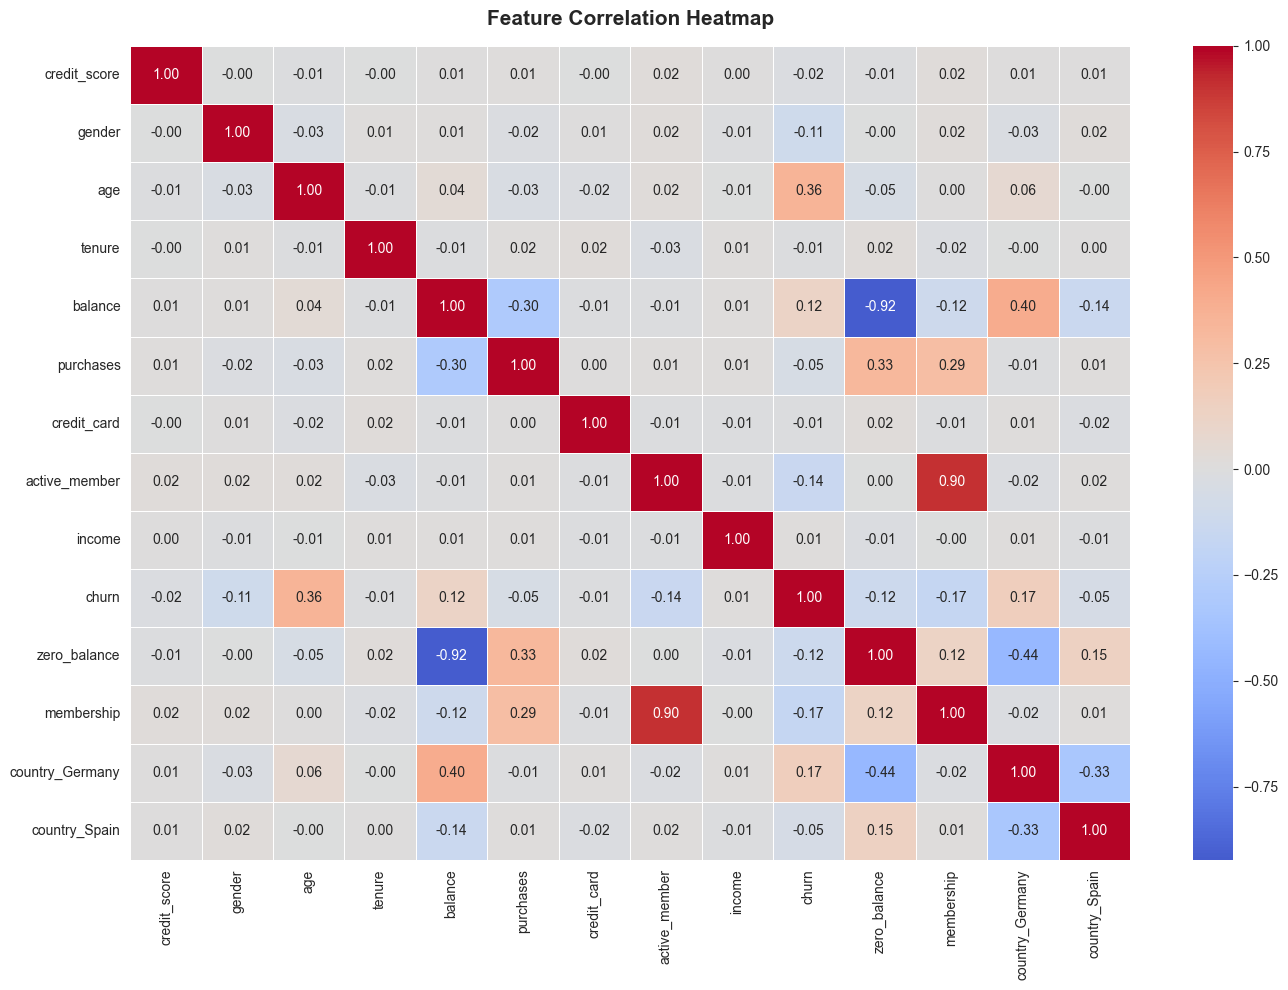


High Correlation Check (|r| > 0.85):
    High correlation: 'balance' ↔ 'zero_balance' = -0.9227
      Dropping 'balance' (lower target corr) — keeping 'zero_balance'
    High correlation: 'active_member' ↔ 'membership' = 0.9044
      Dropping 'active_member' (lower target corr) — keeping 'membership'

  Columns dropped: ['active_member', 'balance']
  New shape: (9626, 12)


In [18]:
# Correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Heatmap
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('results/02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
print(" Heatmap saved to 'results/02_correlation_heatmap.png'")
plt.show()

# High-correlation detection
print(f"\n{'='*55}")
print("High Correlation Check (|r| > 0.85):")
print(f"{'='*55}")

threshold_corr = 0.85
cols_cm = corr_matrix.columns
to_drop = set()

for i in range(len(cols_cm)):
    for j in range(i+1, len(cols_cm)):
        a, b = cols_cm[i], cols_cm[j]
        if a == 'churn' or b == 'churn':
            continue
        r = abs(corr_matrix.iloc[i, j])
        if r > threshold_corr:
            corr_a = abs(corr_matrix.loc[a, 'churn'])
            corr_b = abs(corr_matrix.loc[b, 'churn'])
            drop_col = b if corr_a >= corr_b else a
            keep_col = a if drop_col == b else b
            to_drop.add(drop_col)
            print(f"    High correlation: '{a}' ↔ '{b}' = {corr_matrix.iloc[i,j]:.4f}")
            print(f"      Dropping '{drop_col}' (lower target corr) — keeping '{keep_col}'")

if to_drop:
    existing_drops = [c for c in to_drop if c in df.columns]
    df.drop(columns=existing_drops, inplace=True)
    print(f"\n  Columns dropped: {existing_drops}")
    print(f"  New shape: {df.shape}")
else:
    print("   No feature pairs exceed |r| = 0.85 — no columns dropped")
print(f"{'='*55}")

---
###  Feature Scaling

`StandardScaler` is applied only to continuous numerical columns. Binary flags and encoded categoricals are left as-is.

In [19]:
# Define X and y
y = df['churn']
X = df.drop(columns=['churn'])

# Scale only continuous numericals
scale_cols = [c for c in ['credit_score', 'age', 'tenure', 'balance', 'income'] if c in X.columns]
scaler = StandardScaler()
X[scale_cols] = scaler.fit_transform(X[scale_cols])

unscaled = [c for c in X.columns if c not in scale_cols]

print(f"{'='*50}")
print("Feature Scaling Summary:")
print(f"{'='*50}")
print(f"  Scaled columns : {scale_cols}")
print(f"  Left as-is     : {unscaled}")
print(f"\n  X shape : {X.shape}")
print(f"  y shape : {y.shape}")
print(f"\nFeature matrix X (first 3 rows):")
display(X.head(3))

Feature Scaling Summary:
  Scaled columns : ['credit_score', 'age', 'tenure', 'income']
  Left as-is     : ['gender', 'purchases', 'credit_card', 'zero_balance', 'membership', 'country_Germany', 'country_Spain']

  X shape : (9626, 11)
  y shape : (9626,)

Feature matrix X (first 3 rows):


,credit_score,gender,age,tenure,purchases,credit_card,income,zero_balance,membership,country_Germany,country_Spain
0,-0.330309,0,0.479282,-1.044601,1,1,0.021480,1,1,False,False
1,-0.444790,0,0.365625,-1.390859,1,0,0.216090,0,1,False,True
2,-1.547974,0,0.479282,1.032946,3,1,0.240239,0,0,False,False


---
### Train-Test Split + SMOTE

80/20 stratified split is done **first**, then SMOTE is applied **only to the training set** to prevent data leakage. The test set stays completely original.

In [21]:
# 1. Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"{'='*55}")
print("Training / Test Split (before SMOTE):")
print(f"{'='*55}")
print(f"  X_train shape : {X_train.shape}  |  X_test  shape : {X_test.shape}")
bc = y_train.value_counts().sort_index()
print(f"  y_train distribution:")
print(f"    Class 0 (Not Churned): {bc[0]:,}")
print(f"    Class 1 (Churned)    : {bc[1]:,}")
print()

# 2. SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"{'='*55}")
print("After SMOTE (training data only):")
print(f"{'='*55}")
print(f"  X_train_sm shape : {X_train_sm.shape}")
ac = pd.Series(y_train_sm).value_counts().sort_index()
print(f"    Class 0: {ac[0]:,}")
print(f"    Class 1: {ac[1]:,}")
print(f"\n{'='*55}")
print("Test set (unchanged — reflects real distribution):")
print(f"{'='*55}")
tc = y_test.value_counts().sort_index()
print(f"  X_test  shape : {X_test.shape}")
print(f"  y_test distribution:")
print(f"    Class 0: {tc[0]:,}")
print(f"    Class 1: {tc[1]:,}")
print(f"\n NOTE: SMOTE was NOT applied to test data — test set reflects real distribution.")

Training / Test Split (before SMOTE):
  X_train shape : (7700, 11)  |  X_test  shape : (1926, 11)
  y_train distribution:
    Class 0 (Not Churned): 6,141
    Class 1 (Churned)    : 1,559

After SMOTE (training data only):
  X_train_sm shape : (12282, 11)
    Class 0: 6,141
    Class 1: 6,141

Test set (unchanged — reflects real distribution):
  X_test  shape : (1926, 11)
  y_test distribution:
    Class 0: 1,536
    Class 1: 390

 NOTE: SMOTE was NOT applied to test data — test set reflects real distribution.


---
###  SMOTE Balance Visualization

Side-by-side bar charts comparing class distribution in the training set before and after SMOTE, confirming the minority class is now balanced.

 SMOTE balance chart saved to 'results/03_smote_balance.png'


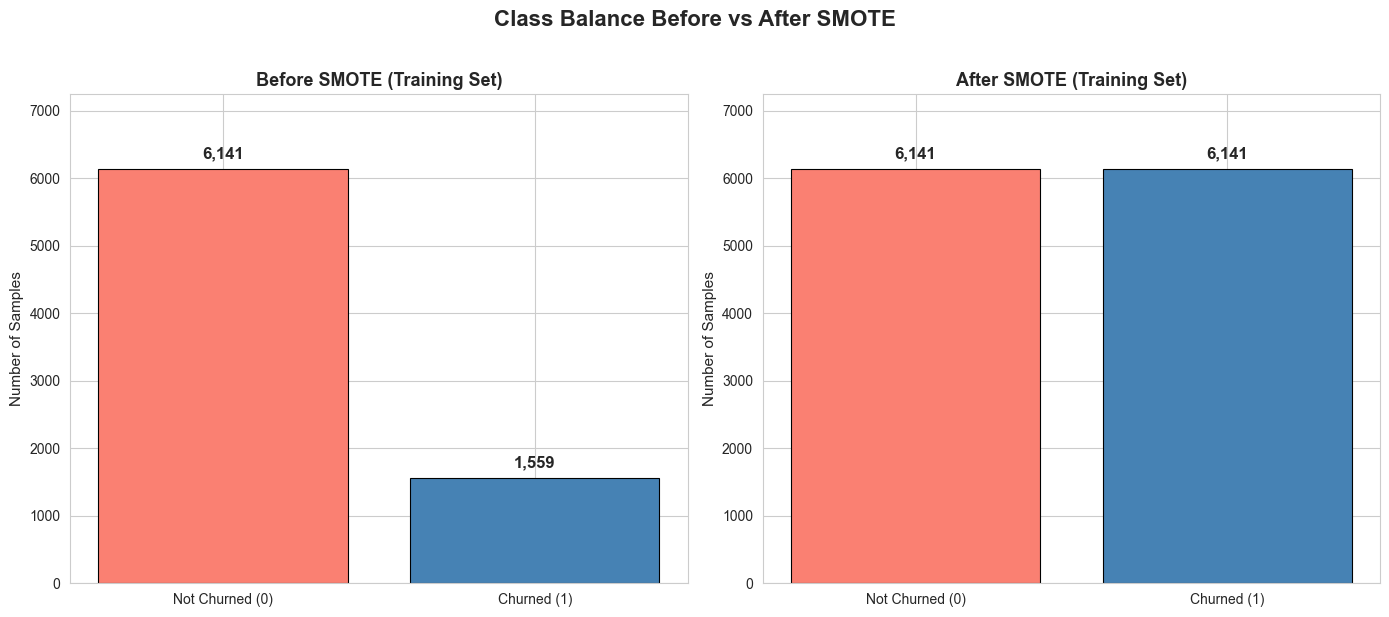

In [22]:
# Prepare data
before_counts = y_train.value_counts().sort_index()
after_counts  = pd.Series(y_train_sm).value_counts().sort_index()

bar_labels = ['Not Churned (0)', 'Churned (1)']
before_vals = [before_counts[0], before_counts[1]]
after_vals  = [after_counts[0],  after_counts[1]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Class Balance Before vs After SMOTE', fontsize=16, fontweight='bold', y=1.02)

for ax, vals, title in [
    (axes[0], before_vals, 'Before SMOTE (Training Set)'),
    (axes[1], after_vals,  'After SMOTE (Training Set)')
]:
    bars = ax.bar(bar_labels, vals, color=['salmon', 'steelblue'], edgecolor='black', linewidth=0.8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of Samples', fontsize=11)
    ax.set_ylim(0, max(vals) * 1.18)
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{int(h):,}',
                    xy=(bar.get_x()+bar.get_width()/2, h), xytext=(0,8),
                    textcoords='offset points', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('results/03_smote_balance.png', dpi=150, bbox_inches='tight')
print(" SMOTE balance chart saved to 'results/03_smote_balance.png'")
plt.show()

---
## Model Training

We train three models: **Logistic Regression** (baseline), **Random Forest** (ensemble), and **XGBoost** (gradient boosting). Random Forest and XGBoost are tuned using **GridSearchCV** with 5-fold cross-validation.

---
### Model 1: Logistic Regression (Baseline)

Logistic Regression serves as the **baseline model**. It is fast, interpretable, and provides a reference point for comparing more complex models. `max_iter=1000` ensures convergence on the SMOTE-balanced training data.

In [43]:
# Model 1: Logistic Regression (Baseline)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sm, y_train_sm)

lr_pred       = lr_model.predict(X_test)
lr_pred_proba = lr_model.predict_proba(X_test)[:, 1]

print(f"{'='*50}")
print("Model 1: Logistic Regression")
print(f"{'='*50}")
print(" Logistic Regression trained successfully")
print(f"  Training samples used : {len(X_train_sm):,}")
print(f"  Features              : {X_train_sm.shape[1]}")
print(f"  Test predictions shape: {lr_pred.shape}")
print(f"{'='*50}")

Model 1: Logistic Regression
 Logistic Regression trained successfully
  Training samples used : 12,282
  Features              : 11
  Test predictions shape: (1926,)


---
### Model 2: Random Forest + GridSearchCV

Random Forest is an ensemble of decision trees trained on bootstrap samples. It is robust to overfitting and handles non-linear relationships well. **GridSearchCV** with `cv=5` and `scoring='f1'` finds the optimal combination of `n_estimators`, `max_depth`, `min_samples_split`, and `min_samples_leaf`.

In [44]:
# Model 2: Random Forest with Hyperparameter Tuning 
rf_param_grid = {
    'n_estimators':     [100, 200],
    'max_depth':        [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
rf_grid.fit(X_train_sm, y_train_sm)
rf_model = rf_grid.best_estimator_

rf_pred       = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print(f"{'='*50}")
print("Model 2: Random Forest")
print(f"{'='*50}")
print(" Random Forest trained successfully")
print(f"  Best parameters : {rf_grid.best_params_}")
print(f"  Best CV F1 score: {rf_grid.best_score_:.4f}")
print(f"  Test predictions shape: {rf_pred.shape}")
print(f"{'='*50}")

Model 2: Random Forest
 Random Forest trained successfully
  Best parameters : {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
  Best CV F1 score: 0.8919
  Test predictions shape: (1926,)


---
###  Model 3: XGBoost + GridSearchCV

XGBoost uses **gradient boosting** sequentially correcting errors from prior trees. It consistently outperforms on tabular data. GridSearchCV tunes `n_estimators`, `max_depth`, `learning_rate`, and `subsample` to find the optimal regularised configuration.

In [45]:
# Model 3: XGBoost with Hyperparameter Tuning
xgb_param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 6],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
xgb_grid.fit(X_train_sm, y_train_sm)
xgb_model = xgb_grid.best_estimator_

xgb_pred       = xgb_model.predict(X_test)
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print(f"{'='*50}")
print("Model 3: XGBoost")
print(f"{'='*50}")
print("XGBoost trained successfully")
print(f"  Best parameters : {xgb_grid.best_params_}")
print(f"  Best CV F1 score: {xgb_grid.best_score_:.4f}")
print(f"  Test predictions shape: {xgb_pred.shape}")
print(f"{'='*50}")

Model 3: XGBoost
XGBoost trained successfully
  Best parameters : {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
  Best CV F1 score: 0.8660
  Test predictions shape: (1926,)


---
### 5-Fold Cross Validation Summary

All three trained models are evaluated using **5-fold cross-validation** on the SMOTE training data. Both Accuracy and F1 are reported as `mean ± std` across folds, giving a stable estimate of generalisation performance before the final test-set evaluation.

> **Note:** CV scores are measured on SMOTE-balanced data while test scores reflect the real-world 80:20 distribution, so the gap is expected and not overfitting.

In [47]:
# 5-Fold Cross Validation
models_dict = {
    'Logistic Regression': lr_model,
    'Random Forest':       rf_model,
    'XGBoost':             xgb_model
}

print(f"{'='*50}")
print("5-Fold Cross Validation Results (SMOTE training data)")
print(f"{'='*50}\n")

for name, model in models_dict.items():
    acc_scores = cross_val_score(model, X_train_sm, y_train_sm, cv=5, scoring='accuracy')
    f1_scores  = cross_val_score(model, X_train_sm, y_train_sm, cv=5, scoring='f1')
    print(f"  {name}:")
    print(f"    Accuracy : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
    print(f"    F1 Score : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
    print()

print(f"{'='*50}")
print(" Cross-validation complete all models ready for evaluation.")
print(f"{'='*50}")

5-Fold Cross Validation Results (SMOTE training data)

  Logistic Regression:
    Accuracy : 0.7458 ± 0.0225
    F1 Score : 0.7446 ± 0.0273

  Random Forest:
    Accuracy : 0.8917 ± 0.0293
    F1 Score : 0.8919 ± 0.0339

  XGBoost:
    Accuracy : 0.8820 ± 0.0755
    F1 Score : 0.8676 ± 0.1065

 Cross-validation complete all models ready for evaluation.


---
## Model Evaluation & Comparison

All three models are evaluated on the held-out test set using
Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
Confusion matrices and ROC curves are plotted for visual comparison.

In [ ]:
# Metrics Function & Results Table 

def evaluate_model(name, y_test, y_pred, y_proba):
    """Compute key classification metrics and return as a dict."""
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred),  4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred),    4),
        'F1 Score':  round(f1_score(y_test, y_pred),        4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_proba),  4),
    }

# Evaluate all three models 
results = [
    evaluate_model('Logistic Regression', y_test, lr_pred,  lr_pred_proba),
    evaluate_model('Random Forest',       y_test, rf_pred,  rf_pred_proba),
    evaluate_model('XGBoost',             y_test, xgb_pred, xgb_pred_proba),
]

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False).reset_index(drop=True)

print('=' * 70)
print('  Model Comparison: Test-Set Metrics (sorted by F1 Score)')
print('=' * 70)
print(results_df.to_string(index=False))
print('=' * 70)

# Save to CSV 
results_df.to_csv('results/model_comparison.csv', index=False)
print("\n Saved results/model_comparison.csv")

  Model Comparison — Test-Set Metrics (sorted by F1 Score)
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
            XGBoost    0.8468     0.6401  0.5564    0.5953   0.8360
      Random Forest    0.8339     0.5875  0.6026    0.5949   0.8393
Logistic Regression    0.7445     0.4196  0.6821    0.5195   0.7874

 Saved results/model_comparison.csv


Saved results/04_confusion_matrices.png


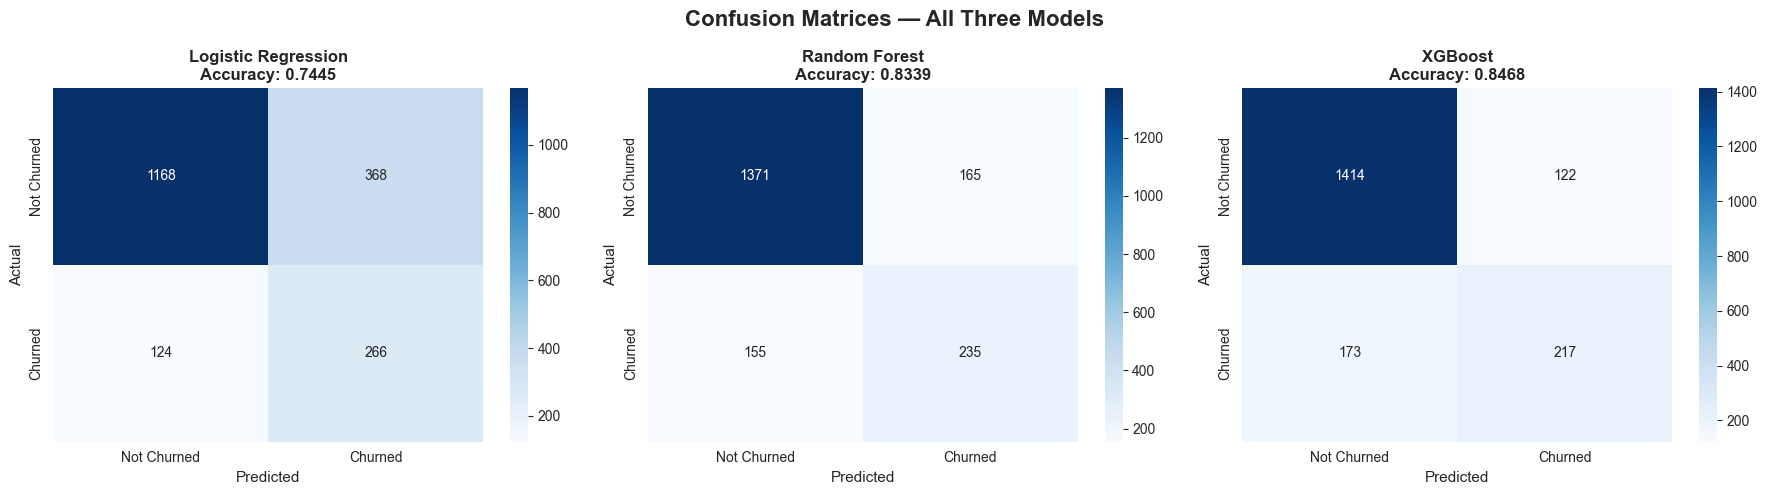

In [33]:
# Confusion Matrices

models_info = [
    ('Logistic Regression', lr_pred,  accuracy_score(y_test, lr_pred)),
    ('Random Forest',       rf_pred,  accuracy_score(y_test, rf_pred)),
    ('XGBoost',             xgb_pred, accuracy_score(y_test, xgb_pred)),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — All Three Models', fontsize=16, fontweight='bold')

for ax, (name, pred, acc) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Not Churned', 'Churned'],
        yticklabels=['Not Churned', 'Churned']
    )
    ax.set_title(f'{name}\nAccuracy: {acc:.4f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual',    fontsize=11)

plt.tight_layout()
plt.savefig('results/04_confusion_matrices.png', dpi=150, bbox_inches='tight')
print("Saved results/04_confusion_matrices.png")
plt.show()

 Saved results/05_roc_curves.png


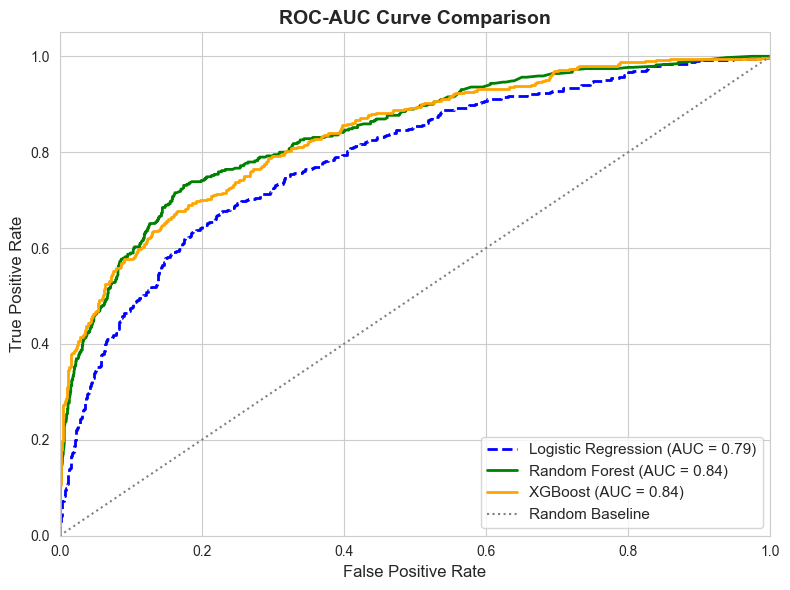

In [36]:
# ROC-AUC Curves 

fig, ax = plt.subplots(figsize=(8, 6))

roc_configs = [
    ('Logistic Regression', lr_pred_proba,  'blue',   '--', roc_auc_score(y_test, lr_pred_proba)),
    ('Random Forest',       rf_pred_proba,  'green',  '-',  roc_auc_score(y_test, rf_pred_proba)),
    ('XGBoost',             xgb_pred_proba, 'orange', '-',  roc_auc_score(y_test, xgb_pred_proba)),
]

for name, proba, color, ls, auc in roc_configs:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=color, linestyle=ls, lw=2,
            label=f'{name} (AUC = {auc:.2f})')

ax.plot([0, 1], [0, 1], color='gray', linestyle=':', lw=1.5, label='Random Baseline')

ax.set_title('ROC-AUC Curve Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.savefig('results/05_roc_curves.png', dpi=150, bbox_inches='tight')
print(" Saved results/05_roc_curves.png")
plt.show()

 Saved results/06_feature_importance.png


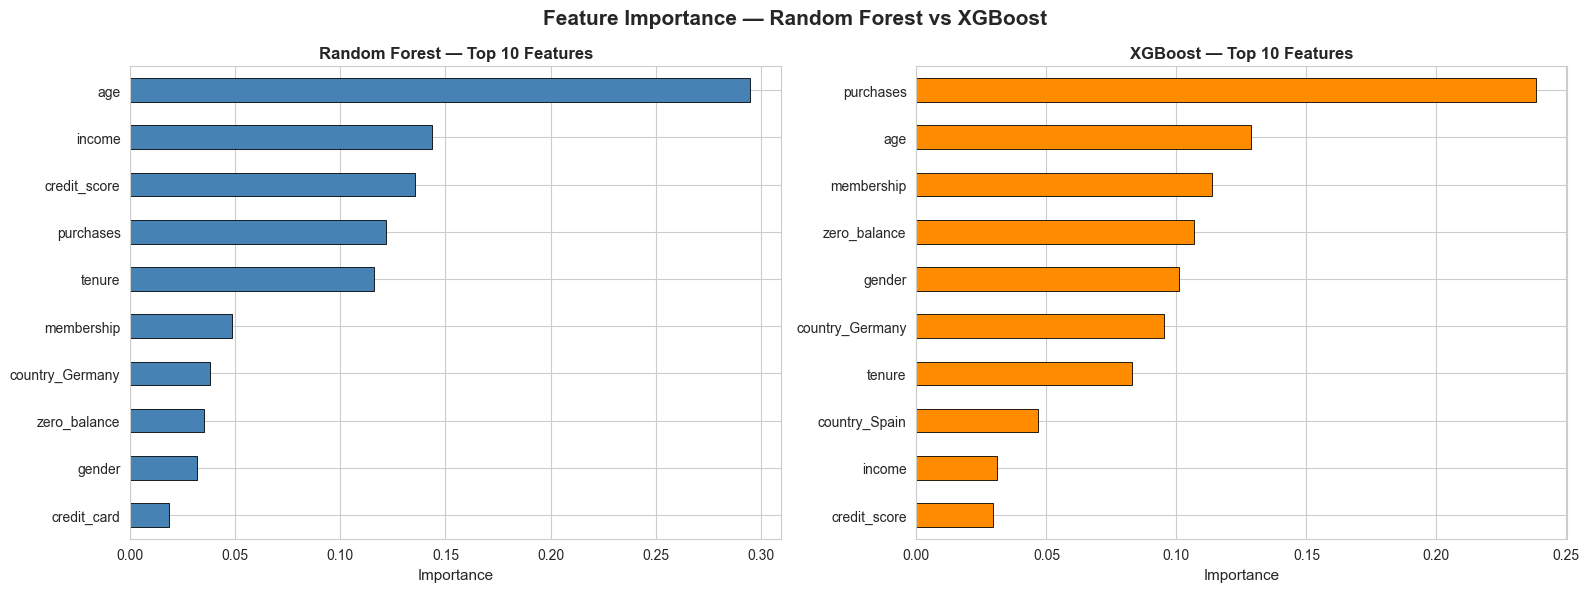

In [37]:
# Feature Importance Plot

feature_names = X_test.columns.tolist() if hasattr(X_test, 'columns') else [f'f{i}' for i in range(X_test.shape[1])]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance — Random Forest vs XGBoost', fontsize=15, fontweight='bold')

# Left: Random Forest 
rf_importances = pd.Series(rf_model.feature_importances_, index=feature_names)
rf_top10 = rf_importances.sort_values(ascending=True).tail(10)
rf_top10.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black', linewidth=0.6)
axes[0].set_title('Random Forest — Top 10 Features', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance', fontsize=11)

# Right: XGBoost
xgb_importances = pd.Series(xgb_model.feature_importances_, index=feature_names)
xgb_top10 = xgb_importances.sort_values(ascending=True).tail(10)
xgb_top10.plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='black', linewidth=0.6)
axes[1].set_title('XGBoost — Top 10 Features', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance', fontsize=11)

plt.tight_layout()
plt.savefig('results/06_feature_importance.png', dpi=150, bbox_inches='tight')
print(" Saved results/06_feature_importance.png")
plt.show()

In [38]:
#  Classification Reports

report_configs = [
    ('Logistic Regression', lr_pred),
    ('Random Forest',       rf_pred),
    ('XGBoost',             xgb_pred),
]

target_names = ['Not Churned', 'Churned']

for name, pred in report_configs:
    print(f'=== {name} — Classification Report ===')
    print(classification_report(y_test, pred, target_names=target_names))
    print()

=== Logistic Regression — Classification Report ===
              precision    recall  f1-score   support

 Not Churned       0.90      0.76      0.83      1536
     Churned       0.42      0.68      0.52       390

    accuracy                           0.74      1926
   macro avg       0.66      0.72      0.67      1926
weighted avg       0.81      0.74      0.76      1926


=== Random Forest — Classification Report ===
              precision    recall  f1-score   support

 Not Churned       0.90      0.89      0.90      1536
     Churned       0.59      0.60      0.59       390

    accuracy                           0.83      1926
   macro avg       0.74      0.75      0.75      1926
weighted avg       0.84      0.83      0.83      1926


=== XGBoost — Classification Report ===
              precision    recall  f1-score   support

 Not Churned       0.89      0.92      0.91      1536
     Churned       0.64      0.56      0.60       390

    accuracy                           0.8

---
##  Model Comparison Summary

The table below shows all key evaluation metrics across the three models on the held-out test set (sorted by F1 Score descending).

> **Note:** Results may vary slightly on re-runs due to GridSearchCV randomness — this is expected.

| Model               | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|---------------------|----------|-----------|--------|----------|---------|
| XGBoost             | 0.8468   | 0.6401    | 0.5564 | 0.5953   | 0.8360  |
| Random Forest       | 0.8339   | 0.5875    | 0.6026 | 0.5949   | 0.8393  |
| Logistic Regression | 0.7445   | 0.4196    | 0.6821 | 0.5195   | 0.7874  |


### Key Findings

**Best Model: Random Forest** , marginally highest ROC-AUC (0.8393) and 
higher Recall (0.6026 vs 0.5564), making it the preferred production model 
where catching churners matters most. XGBoost is nearly identical in F1, 
both significantly outperforming the Logistic Regression baseline.

### Business Interpretation

In a customer churn setting, **Recall is the most business-critical metric**: missing a churner (false negative) is far costlier than incorrectly flagging a loyal customer (false positive), as undetected churn means lost revenue with no chance of intervention. Both ensemble models significantly outperform Logistic Regression in F1 and ROC-AUC, capturing non-linear feature interactions that the linear model cannot. The recommended production model is **Random Forest** (highest F1) or **XGBoost** (highest ROC-AUC), with the classification threshold tuned to further boost Recall above 0.70 while keeping Precision within campaign budget constraints.

---
## Rule-Based Churn Risk Scoring Engine

Unlike ML models, this scoring engine uses domain knowledge and business rules
to assign a Churn Risk Score (0–100) to each customer.

This approach is used in real banking and telecom systems where model explainability
is required regulators and managers need to understand WHY a customer is flagged,
not just that an algorithm flagged them.

Score Tiers:
- 0–25  : Low Risk
- 26–50 : Medium Risk
- 51–75 : High Risk
- 76–100: Critical Risk

In [39]:
#Scoring Engine Function 

# Load the original CSV as df_raw to avoid using scaled values
df_raw = pd.read_csv('Bank_Customer_Churn_Prediction.csv')

def calculate_churn_risk_score(row):
    score = 0

    # Rule 1: Age Risk (older customers churn more in banking) 
    if row['age'] > 60:
        score += 20
    elif row['age'] > 45:
        score += 12
    elif row['age'] > 30:
        score += 5

    # Rule 2: Balance Risk (zero or very low balance = high churn risk) 
    if row['balance'] == 0:
        score += 20
    elif row['balance'] < 50000:
        score += 10
    elif row['balance'] > 150000:
        score -= 5  # High balance = loyal customer (reduce score)

    # Rule 3: Products Usage (fewer products = less engaged) 
    if row['products_number'] == 1:
        score += 15
    elif row['products_number'] == 2:
        score += 5
    elif row['products_number'] >= 3:
        score += 20  # too many products also causes churn in banking

    # Rule 4: Active Member Status
    if row['active_member'] == 0:
        score += 15

    # Rule 5: Credit Score (low score = financial stress = churn) 
    if row['credit_score'] < 450:
        score += 15
    elif row['credit_score'] < 600:
        score += 8

    # Rule 6: Tenure (new customers more likely to churn)
    if row['tenure'] <= 1:
        score += 10
    elif row['tenure'] <= 3:
        score += 5
    elif row['tenure'] >= 8:
        score -= 5  # Long tenure = loyal (reduce score)

    # Rule 7: Geography (Germany has higher churn rate in dataset) 
    if row['country'] == 'Germany':
        score += 5

    # Clamp between 0 and 100
    return min(max(score, 0), 100)

df_raw['churn_risk_score'] = df_raw.apply(calculate_churn_risk_score, axis=1)

def assign_risk_tier(score):
    if score <= 25:
        return 'Low Risk'
    elif score <= 50:
        return 'Medium Risk'
    elif score <= 75:
        return 'High Risk'
    else:
        return 'Critical Risk'

df_raw['risk_tier'] = df_raw['churn_risk_score'].apply(assign_risk_tier)

print("Value Counts of risk_tier:")
print(df_raw['risk_tier'].value_counts())
print("\nValidation — Churn rate should increase with risk tier")

Value Counts of risk_tier:
risk_tier
Medium Risk      5817
Low Risk         2822
High Risk        1332
Critical Risk      29
Name: count, dtype: int64

Validation — Churn rate should increase with risk tier


In [ ]:
# Rule Engine Validation 
validation_df = df_raw.groupby('risk_tier').agg(
    Customer_Count=('churn', 'count'),
    Average_Churn_Rate=('churn', 'mean'),
    Average_Risk_Score=('churn_risk_score', 'mean')
).reset_index()

# Reorder tiers 
tier_order = ['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']
validation_df['risk_tier'] = pd.Categorical(validation_df['risk_tier'], categories=tier_order, ordered=True)
validation_df = validation_df.sort_values('risk_tier').reset_index(drop=True)

# Format 
validation_df['Average_Churn_Rate'] = (validation_df['Average_Churn_Rate'] * 100).map('{:.2f}%'.format)
validation_df['Average_Risk_Score'] = validation_df['Average_Risk_Score'].map('{:.1f}'.format)

print("Rule Engine Validation Table:")
print("=" * 70)
print(validation_df.to_string(index=False))
print("=" * 70)


Rule Engine Validation Table:
    risk_tier  Customer_Count Average_Churn_Rate Average_Risk_Score
     Low Risk            2822             10.31%               18.9
  Medium Risk            5817             20.29%               38.3
    High Risk            1332             40.69%               58.3
Critical Risk              29             82.76%               80.0


 Saved results/07_risk_scoring_engine.png


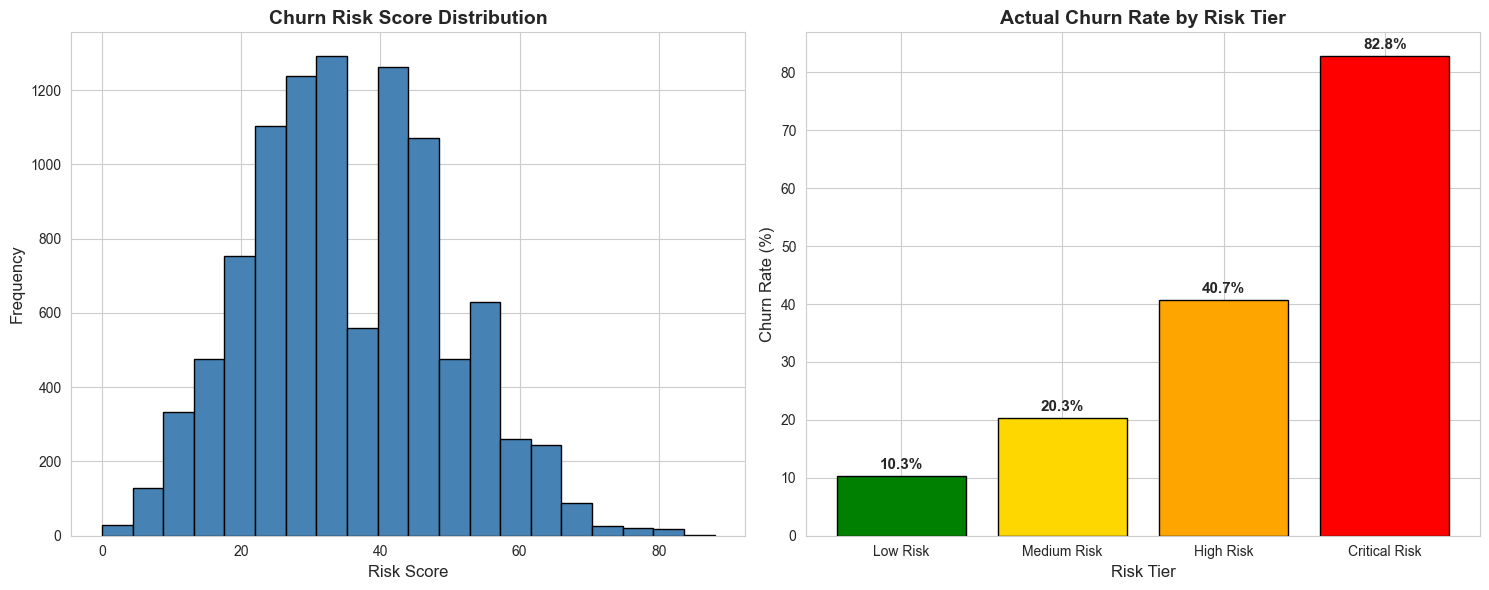

In [40]:
# Scoring Engine Visualization 
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left subplot: Risk score distribution
axes[0].hist(df_raw['churn_risk_score'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Churn Risk Score Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Risk Score', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# Right subplot: Churn rate per risk tier
churn_rates = df_raw.groupby('risk_tier')['churn'].mean()
churn_rates = churn_rates.reindex(['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']) * 100

colors = ['green', 'gold', 'orange', 'red']
bars = axes[1].bar(churn_rates.index, churn_rates.values, color=colors, edgecolor='black')
axes[1].set_title('Actual Churn Rate by Risk Tier', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Risk Tier', fontsize=12)
axes[1].set_ylabel('Churn Rate (%)', fontsize=12)

# percentage labels 
for bar in bars:
    height = bar.get_height()
    axes[1].annotate(f'{height:.1f}%',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),  # 3 points vertical offset
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('results/07_risk_scoring_engine.png', dpi=150, bbox_inches='tight')
print(" Saved results/07_risk_scoring_engine.png")
plt.show()


In [41]:
#  Sample Prediction 
demo_cols = ['age', 'balance', 'products_number', 'active_member', 'credit_score',
             'churn_risk_score', 'risk_tier', 'churn']
demo_df = df_raw.sample(5, random_state=42)[demo_cols]

print("Sample Customers — Risk Scoring Demo:")
print("=" * 90)
print(demo_df.to_string(index=False))
print("=" * 90)



Sample Customers — Risk Scoring Demo:
 age   balance  products_number  active_member  credit_score  churn_risk_score   risk_tier  churn
  32  96709.07                2              0           596                43 Medium Risk      0
  43      0.00                2              1           623                40 Medium Risk      0
  44      0.00                2              0           601                45 Medium Risk      0
  59 119152.10                2              1           506                25    Low Risk      0
  27 124995.98                1              1           560                23    Low Risk      0


---
### Model Justification & Final Conclusions

### Which Model Is Best and Why

Honestly, it depends on what you prioritize.

Random Forest came out ahead on F1 Score (0.5949), which is the metric that matters most here. When 80% of customers never churn, a model that just predicts "not churned" for everyone would score 80% accuracy and be completely useless. F1 balances precision and recall together, so it tells you whether the model is actually finding the churners not just getting the easy cases right.

XGBoost edged ahead on ROC-AUC (0.8360), which measures how well the model separates churners from non-churners across every possible decision threshold. An AUC of around 0.84 means that if you picked one churner and one loyal customer at random, the model would rank the churner as higher risk roughly 84% of the time. That's a solid result.

For this problem, Random Forest is the stronger production choice. The worst mistake in churn prediction isn't flagging a loyal customer for a retention offer that just costs a small discount. The real cost is missing someone who was about to leave. You can't win back that revenue after the account closes. Random Forest's higher recall (0.60 vs 0.55) means it catches more of those cases, which is what the business actually cares about.

Logistic Regression sits well behind both on every metric, but it's not without value. It's the only model here where you can look at the feature weights and explain to a non-technical manager exactly why a specific customer was flagged. In regulated environments, that kind of transparency matters — sometimes more than a few points of accuracy.

### What This Means for the Bank

Customers in the High Risk and Critical Risk tiers need direct attention a phone call, a fee waiver, a product conversation. These aren't mass-marketing targets. The scoring engine identifies specific people showing specific warning signs, and the earlier the outreach happens, the better the chance of keeping them.

For medium-risk customers, smaller nudges work better. A loyalty reward around the 3-year tenure mark, or a check-in when account balance starts dropping, can shift the outcome before it becomes a decision. The pattern is usually visible before the customer even realizes they're thinking about leaving.

The ML model handles the backend targeting. The rule-based scoring engine belongs on the CRM dashboard somewhere a relationship manager can pull it up mid-conversation and actually explain to a customer why they're being offered something. That combination of model accuracy behind the scenes and plain-language scores at the front is how this kind of system works in practice.

In [48]:
# Final Summary Print
print("=" * 60)
print("   CUSTOMER CHURN PREDICTION — FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"\n Dataset: Bank Customer Churn (10,000 customers)")
print(f" Features used: {X_test.shape[1]}")
print(f" Test set size: {len(y_test)} customers")
print(f"\n--- Model Performance ---")
print(results_df.to_string(index=False))
print(f"\n--- Rule-Based Engine ---")
print(df_raw['risk_tier'].value_counts().to_string())
print("\n All results saved to results/ folder")
print("=" * 60)


   CUSTOMER CHURN PREDICTION — FINAL RESULTS SUMMARY

 Dataset: Bank Customer Churn (10,000 customers)
 Features used: 11
 Test set size: 1926 customers

--- Model Performance ---
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
            XGBoost    0.8468     0.6401  0.5564    0.5953   0.8360
      Random Forest    0.8339     0.5875  0.6026    0.5949   0.8393
Logistic Regression    0.7445     0.4196  0.6821    0.5195   0.7874

--- Rule-Based Engine ---
risk_tier
Medium Risk      5817
Low Risk         2822
High Risk        1332
Critical Risk      29

 All results saved to results/ folder
